Mount Drive and set paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATA_ROOT = '/content/drive/MyDrive/ImageCaptionProject/Flickr8k'
IMG_DIR   = f'{DATA_ROOT}' # Corrected: Images are directly in DATA_ROOT
CAP_FILE  = f'{DATA_ROOT}/captions.txt'

In [3]:
import pandas as pd
caps = open(CAP_FILE).read().split('\n')[:10]
print(caps)

['image,caption', '1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .', '1000268201_693b08cb0e.jpg,A girl going into a wooden building .', '1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .', '1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .', '1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .', '1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting', '1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .', '1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .', '1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .']


Training the CNN + LSTM

In [4]:
# Load captions file into a dictionary:  {image_name: [caption1, caption2, ...]}
captions_dict = {}

with open(CAP_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if len(line) < 5:
            continue
        img, cap = line.split(",", 1)
        if img not in captions_dict:
            captions_dict[img] = []
        captions_dict[img].append(cap)

print("Total images:", len(captions_dict))


Total images: 8092


Generate a caption for one image

In [5]:
!mkdir -p "/content/drive/MyDrive/ImageCaptionProject/saved_model"


In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import os

def show_image_and_captions(img_name):
    # Full image path
    img_path = os.path.join(IMG_DIR, img_name)

    # Show image
    img = Image.open(img_path)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Show captions
    print(f"📌 Captions for: {img_name}\n")
    for i, cap in enumerate(captions_dict[img_name], 1):
        print(f"{i}. {cap}")


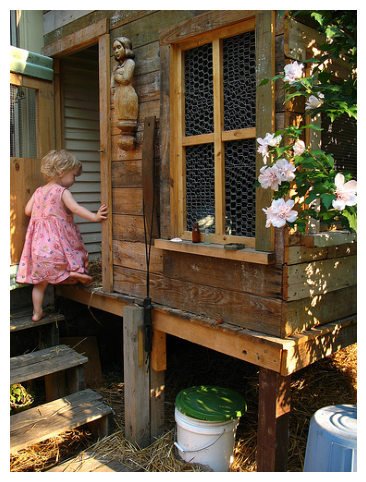

📌 Captions for: 1000268201_693b08cb0e.jpg

1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .


In [7]:
show_image_and_captions("1000268201_693b08cb0e.jpg")

In [8]:
import os

dir_to_check = '/content/drive/MyDrive/ImageCaptionProject/Flickr8k/'

if os.path.exists(dir_to_check):
    print(f"Contents of '{dir_to_check}':")
    for item in os.listdir(dir_to_check):
        print(item)
else:
    print(f"The directory '{dir_to_check}' does NOT exist. Please check the path.")

Contents of '/content/drive/MyDrive/ImageCaptionProject/Flickr8k/':
384465575_31294122c0.jpg
3726120436_740bda8416.jpg
404216567_75b50b5a36.jpg
407008823_bdd7fc6ed5.jpg
3713133789_f05e8daffd.jpg
3751594676_edfbfa0688.jpg
416650559_cd08d3cd96.jpg
3721881082_afe9fc734e.jpg
389643437_9a9830a3ba.jpg
378170167_9b5119d918.jpg
3725177385_62d5e13634.jpg
413231421_43833a11f5.jpg
375384566_254c2362d4.jpg
3747543364_bf5b548527.jpg
421322723_3470543368.jpg
3724150944_fc62e8d5e0.jpg
401476986_73918145a3.jpg
415793623_6c1225ae27.jpg
405961988_fcfe97f31e.jpg
3716244806_97d5a1fb61.jpg
403678611_73978faed7.jpg
419116771_642800891d.jpg
3718076407_0b4588d7bc.jpg
380590140_25b9889772.jpg
3716272233_7845ec5b3e.jpg
412082368_371df946b3.jpg
374567836_3ae12ecffb.jpg
397451339_76a84bd310.jpg
3741827382_71e93298d0.jpg
3727752439_907795603b.jpg
417577408_eb571658c1.jpg
396360611_941e5849a3.jpg
3726076549_0efb38854b.jpg
397601572_9587a39291.jpg
3711030008_3872d0b03f.jpg
3733074526_82aa8d5f8d.jpg
408748500_e8dc8c0

In [9]:
import os

image_directory = '/content/drive/MyDrive/ImageCaptionProject/Flickr8k/Images/'

if os.path.exists(image_directory):
    print(f"Files in '{image_directory}':")
    for filename in os.listdir(image_directory):
        # You can add a filter here if you only want to see image files (e.g., .jpg, .png)
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            print(filename)
else:
    print(f"The directory '{image_directory}' does NOT exist. Please check the path.")

The directory '/content/drive/MyDrive/ImageCaptionProject/Flickr8k/Images/' does NOT exist. Please check the path.


In [10]:
import os

image_path_to_verify = '/content/drive/MyDrive/ImageCaptionProject/Flickr8k/Images/1000268201_693b08cb0e.jpg'

if os.path.exists(image_path_to_verify):
    print(f"The file '{image_path_to_verify}' exists.")
else:
    print(f"The file '{image_path_to_verify}' does NOT exist. Please check the path and filename.")

The file '/content/drive/MyDrive/ImageCaptionProject/Flickr8k/Images/1000268201_693b08cb0e.jpg' does NOT exist. Please check the path and filename.


In [11]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


Dataset and DataLoader

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, random

MAX_LEN = 20

# Image preprocessing
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def encode_caption(text, max_len=MAX_LEN):
    tokens = text.split()
    ids = [stoi.get(w, UNK) for w in tokens]
    ids = ids[:max_len] + [PAD] * max(0, max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)

class Flickr8kDataset(Dataset):
    def __init__(self, img_dir, caps_by_img, split='train',
                 train_ratio=0.8, seed=42):
        super().__init__()
        random.seed(seed)
        imgs = list(caps_by_img.keys())
        random.shuffle(imgs)
        n_train = int(len(imgs) * train_ratio)

        self.img_dir = img_dir
        self.caps_by_img = caps_by_img

        if split == 'train':
            self.imgs = imgs[:n_train]
        else:
            self.imgs = imgs[n_train:]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        image = tfm(image)

        caps = self.caps_by_img[img_name]
        cap_text = random.choice(caps)         # one of the 5 captions
        cap_ids = encode_caption(cap_text)

        return image, cap_ids, img_name

# create train/val split
train_ds = Flickr8kDataset(IMG_DIR, captions_dict, split='train')
val_ds   = Flickr8kDataset(IMG_DIR, captions_dict, split='val')

print("Train size:", len(train_ds), "Val size:", len(val_ds))


Train size: 6473 Val size: 1619


In [14]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import random
import os

MAX_LEN = 20

# Encode captions
def encode_caption(text, max_len=MAX_LEN):
    tokens = text.split()
    ids = [stoi.get(w, UNK) for w in tokens]
    ids = ids[:max_len]
    ids = ids + [PAD] * (max_len - len(ids))
    tgt = ids[1:] + [EOS]     # shift for decoder
    return torch.tensor(ids), torch.tensor(tgt)


# Image transforms
from torchvision import transforms
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


class Flickr8kDataset(Dataset):
    def __init__(self, img_dir, captions_dict, split='train'):
        self.img_dir = img_dir
        self.captions_dict = captions_dict

        all_imgs = list(captions_dict.keys())
        random.seed(42)
        random.shuffle(all_imgs)

        cut = int(0.8 * len(all_imgs))
        if split == 'train':
            self.images = all_imgs[:cut]
        else:
            self.images = all_imgs[cut:]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert('RGB')
        img = tfm(img)

        caption = random.choice(self.captions_dict[img_name])
        inp, tgt = encode_caption(caption)

        return img, inp, tgt


Read captions, clean them, build vocabulary

In [13]:
import re
from collections import defaultdict, Counter

def clean_text(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

captions_dict = defaultdict(list)

with open(CAP_FILE, "r") as f:
    next(f) # Skip the header line
    for line in f:
        line = line.strip()
        if len(line) < 5:
            continue
        img, cap = line.split(",", 1)
        cap = clean_text(cap)
        cap = f"<bos> {cap} <eos>"
        captions_dict[img].append(cap)

print("Total images:", len(captions_dict))

FREQ_THRESH = 5
counter = Counter()
for caps in captions_dict.values():
    for c in caps:
        counter.update(c.split())

special = ['<pad>', '<bos>', '<eos>', '<unk>']
itos = special + [w for w, c in counter.items() if c >= FREQ_THRESH and w not in special]
stoi = {w: i for i, w in enumerate(itos)}

PAD = stoi['<pad>']
BOS = stoi['<bos>']
EOS = stoi['<eos>']
UNK = stoi['<unk>']

vocab_size = len(itos)
print("Vocab size:", vocab_size)


Total images: 8091
Vocab size: 2982


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, random

MAX_LEN = 20

# image transforms (resize + normalize)
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def encode_caption(text, max_len=MAX_LEN):
    tokens = text.split()
    ids = [stoi.get(w, UNK) for w in tokens]
    ids = ids[:max_len] + [PAD] * max(0, max_len - len(ids))
    cap_ids = torch.tensor(ids, dtype=torch.long)
    x = cap_ids[:-1] # Input sequence for the decoder
    y = cap_ids[1:]  # Target sequence for loss calculation
    return x, y

class Flickr8kDataset(Dataset):
    def __init__(self, img_dir, caps_by_img, split='train', train_ratio=0.8, seed=42):
        super().__init__()
        random.seed(seed)
        imgs = list(caps_by_img.keys())
        random.shuffle(imgs)
        n_train = int(len(imgs) * train_ratio)

        self.img_dir = img_dir
        self.caps_by_img = caps_by_img

        if split == 'train':
            self.imgs = imgs[:n_train]
        else:
            self.imgs = imgs[n_train:]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        image = tfm(image)

        cap_text = random.choice(self.caps_by_img[img_name])
        x_tokens, y_tokens  = encode_caption(cap_text)   # Now returns two tensors

        return image, x_tokens, y_tokens, img_name

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    xs   = torch.stack([b[1] for b in batch], dim=0) # Stack input tokens
    ys   = torch.stack([b[2] for b in batch], dim=0) # Stack target tokens
    names = [b[3] for b in batch]
    return imgs, xs, ys, names

train_ds = Flickr8kDataset(IMG_DIR, captions_dict, split='train')
val_ds   = Flickr8kDataset(IMG_DIR, captions_dict, split='val')

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

batch = next(iter(train_loader))
print("Images:", batch[0].shape)
print("Inputs:", batch[1].shape)
print("Targets:", batch[2].shape)


Images: torch.Size([64, 3, 224, 224])
Inputs: torch.Size([64, 19])
Targets: torch.Size([64, 19])


CNN Encoder + LSTM Decoder Model

In [16]:
import torch.nn as nn
from torchvision import models

class EncoderCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for p in base.parameters():
            p.requires_grad = False
        self.cnn = nn.Sequential(*list(base.children())[:-1])  # [B,2048,1,1]
        self.fc  = nn.Linear(2048, embed_dim)
        self.bn  = nn.BatchNorm1d(embed_dim)

    def forward(self, x):
        x = self.cnn(x).squeeze(-1).squeeze(-1)  # [B,2048]
        x = self.bn(self.fc(x))                  # [B,embed_dim]
        return x

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, pad_idx=0):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_feats, tokens):
        emb_tokens = self.emb(tokens)        # [B,T,D]
        img_feats  = img_feats.unsqueeze(1)  # [B,1,D]
        lstm_in    = torch.cat([img_feats, emb_tokens], dim=1)  # [B,T+1,D]
        h, _       = self.lstm(lstm_in)      # [B,T+1,H]
        logits     = self.fc(h)              # [B,T+1,V]
        return logits

class CaptionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, pad_idx=0):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)
        self.decoder = DecoderLSTM(vocab_size, embed_dim, hidden_dim, pad_idx)

    def forward(self, images, tokens):
        feats = self.encoder(images)
        logits = self.decoder(feats, tokens)
        return logits


Training loop

In [17]:
import torch
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

model = CaptionModel(vocab_size, embed_dim=256, hidden_dim=512, pad_idx=PAD).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

EPOCHS =  5 # keep small so it finishes for tonight

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, count = 0.0, 0

    with torch.set_grad_enabled(train):
        for imgs, x, y, _ in tqdm(loader):
            imgs, x, y = imgs.to(device), x.to(device), y.to(device)
            logits = model(imgs, x)   # [B,T+1,V]

            T = min(logits.size(1), y.size(1))
            logits = logits[:, :T, :]
            y      = y[:, :T]

            loss = criterion(logits.reshape(-1, vocab_size),
                             y.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total += loss.item()
            count += 1
    return total / max(count, 1)

best_val = 1e9

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


In [18]:
for epoch in range(1, EPOCHS+1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch}: train = {train_loss:.3f}, val = {val_loss:.3f}")

    if val_loss < best_val:
        best_val = val_loss
        # Save model to Google Drive for persistence
        torch.save({
            "model_state": model.state_dict(),
            "itos": itos,
            "stoi": stoi
        }, f"{DATA_ROOT}/best_caption_model.pt") # Use DATA_ROOT for Google Drive path
        print("Saved best model")

100%|██████████| 26/26 [00:09<00:00,  2.67it/s]


Epoch 1: train = 6.059, val = 5.190
Saved best model


100%|██████████| 26/26 [00:08<00:00,  3.23it/s]


Epoch 2: train = 4.997, val = 4.895
Saved best model


100%|██████████| 26/26 [00:07<00:00,  3.31it/s]


Epoch 3: train = 4.746, val = 4.689
Saved best model


100%|██████████| 26/26 [00:07<00:00,  3.25it/s]


Epoch 4: train = 4.561, val = 4.547
Saved best model


100%|██████████| 26/26 [00:07<00:00,  3.34it/s]


Epoch 5: train = 4.441, val = 4.434
Saved best model


Generate caption for one image (for report)

In [19]:
CAP_FILE="/content/captions.txt"
print(CAP_FILE)


/content/captions.txt


In [20]:
from collections import defaultdict

CAP_FILE = f'{DATA_ROOT}/captions.txt' # Corrected path to captions.txt

captions_dict = defaultdict(list)

with open(CAP_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # skip header line "image,caption" if it exists
        if line.lower().startswith("image,caption"):
            continue

        img, cap = line.split(",", 1)
        captions_dict[img].append(cap)

print("Total images:", len(captions_dict))

first_key = next(iter(captions_dict.keys()))
print("Example key:", first_key)


Total images: 8091
Example key: 1000268201_693b08cb0e.jpg


In [21]:
from google.colab import drive
drive.mount('/content/drive')   # if not already mounted

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_PATH = f"{DATA_ROOT}/best_caption_model.pt" # Corrected to point to the model file
checkpoint = torch.load(MODEL_PATH, map_location=device)

model = CaptionModel(vocab_size, embed_dim=256, hidden_dim=512, pad_idx=PAD).to(device)
model.load_state_dict(checkpoint["model_state"])
itos = checkpoint["itos"]
stoi = checkpoint["stoi"]

print("Model loaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded!


In [22]:
def generate_caption(image_path, max_len=30):
    model.eval()
    with torch.no_grad():
        # --------------------
        # 1. Encode image
        # --------------------
        img = Image.open(image_path).convert("RGB")
        img = tfm(img).unsqueeze(0).to(device) # Shape [1, 3, 224, 224]

        feats = model.encoder(img) # Shape [1, embed_dim]

        # First, process the image features through the LSTM to get initial context states.
        # The LSTM's initial hidden/cell states default to zeros if not provided.
        # This first step simulates the DecoderLSTM's `forward` concatenating `img_feats` as the first input.
        initial_lstm_input = feats.unsqueeze(1) # Shape [1, 1, embed_dim]
        # We only care about the resulting hidden and cell states for the next decoding steps.
        # The DecoderLSTM's forward concatenates img_feats with token embeddings. For the first step
        # we simulate this by passing img_feats alone, and then using the resulting states.
        # Note: In the DecoderLSTM implementation, img_feats are prepended to the token sequence.
        # For generation, we start with <bos>, so img_feats act as the 'first token' to set initial state.

        # Initialize hidden and cell states to zeros (default for first call if not provided)
        h_lstm = torch.zeros(model.decoder.lstm.num_layers, 1, model.decoder.lstm.hidden_size).to(device)
        c_lstm = torch.zeros(model.decoder.lstm.num_layers, 1, model.decoder.lstm.hidden_size).to(device)

        # Pass image features as the first 'input' to set the initial context of the LSTM
        # This is a bit of a workaround to integrate the `feats` into the LSTM's state
        # as the `DecoderLSTM` expects `feats` as the very first element of its input sequence.
        # The `DecoderLSTM`'s `forward` method is: `lstm_in = torch.cat([img_feats, emb_tokens], dim=1)`
        # So the `img_feats` are the `0`th element in the sequence.
        # During inference, we effectively pass `img_feats` as the first item to get the initial `h, c`
        # that would correspond to processing the image, before any tokens.
        _, (h_lstm, c_lstm) = model.decoder.lstm(feats.unsqueeze(1), (h_lstm, c_lstm))

        words = []
        cur_token_id = BOS # Start decoding with <bos> token

        # --------------------
        # 2. Decode word-by-word
        # --------------------
        for _ in range(max_len):
            # Embed the current token (e.g., <bos>, or previous predicted word)
            # Shape [1, 1, embed_dim]
            emb = model.decoder.emb(torch.tensor([[cur_token_id]], device=device))

            # Pass the word embedding and the updated LSTM states from the previous step
            # `output` will be [1, 1, hidden_dim]
            # `h_lstm`, `c_lstm` will be the new updated states [num_layers, 1, hidden_size]
            output, (h_lstm, c_lstm) = model.decoder.lstm(emb, (h_lstm, c_lstm))

            # Get logits for the next word from the output of this LSTM step
            # `output.squeeze(1)` converts [1, 1, hidden_dim] to [1, hidden_dim]
            logits = model.decoder.fc(output.squeeze(1))

            next_id = logits.argmax(dim=-1).item()
            next_word = itos[next_id]

            # Stop decoding if <eos> token is predicted
            if next_word == "<eos>":
                break

            # Add valid word to the caption (excluding special tokens like <bos>, <pad>)
            if next_word not in ("<bos>", "<pad>"):
                words.append(next_word)

            # Update the current token for the next iteration
            cur_token_id = next_id

        return " ".join(words)

Test image: 1000268201_693b08cb0e.jpg


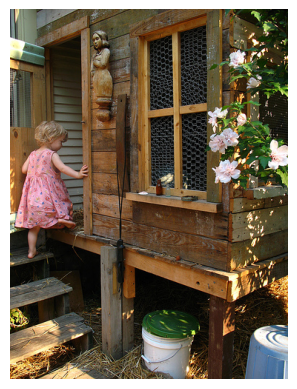

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# choose one real image key
test_name = next(k for k in captions_dict.keys() if k.lower().endswith(('.jpg', '.jpeg')))
test_path = os.path.join(IMG_DIR, test_name)

print("Test image:", test_name)

plt.imshow(Image.open(test_path))
plt.axis("off")
plt.show()


In [25]:
print("Generated caption:")
print(generate_caption(test_path))

print("\nGround-truth captions:")
for c in captions_dict[test_name]:
    print("-", c)

Generated caption:
man on skateboard a

Ground-truth captions:
- A child in a pink dress is climbing up a set of stairs in an entry way .
- A girl going into a wooden building .
- A little girl climbing into a wooden playhouse .
- A little girl climbing the stairs to her playhouse .
- A little girl in a pink dress going into a wooden cabin .


In [26]:
!ls "/content/drive/MyDrive/ImageCaptionProject/saved_model"


best_caption_model.pt


In [27]:
MODEL_PATH = "/content/drive/MyDrive/ImageCaptionProject/saved_model/best_caption_model.pt"

checkpoint = torch.load(MODEL_PATH, map_location=device)

model = CaptionModel(vocab_size, embed_dim=256, hidden_dim=512, pad_idx=PAD).to(device)
model.load_state_dict(checkpoint["model_state"])

itos = checkpoint["itos"]
stoi = checkpoint["stoi"]

print("Model loaded successfully!")


Model loaded successfully!


In [29]:
SAVE_PATH = "/content/drive/MyDrive/ImageCaptionProject/saved_model/best_caption_model.pt"

torch.save({
    "model_state": model.state_dict(),
    "itos": itos,
    "stoi": stoi
}, SAVE_PATH)

print("Model saved to Google Drive!")

Model saved to Google Drive!
